In [1]:
# Make the repo importable from this notebook (it lives in <repo>/jupyternotebooks) and provide what
# `source setup.sh` would give a shell: Jupyter kernels do not source it.
import os, sys
from pathlib import Path
from tqdm import tqdm

REPO = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "setup.sh").is_file()),
    Path("/global/homes/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae"),
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# configs/file_dict.py needs LOCAL_BASE_DIR; take it from setup.sh if the kernel does not have it
if "LOCAL_BASE_DIR" not in os.environ:
    for line in (REPO / "setup.sh").read_text().splitlines():
        if line.startswith("export LOCAL_BASE_DIR="):
            os.environ["LOCAL_BASE_DIR"] = line.split("=", 1)[1].strip().strip('"').strip("'")

print("repo:", REPO, "\nLOCAL_BASE_DIR:", os.environ["LOCAL_BASE_DIR"])

import copy
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import AdamW

from src.processing import process_delphes_events, build_arrays, presence_mask, FEATURES, VALID
from src.processing import compute_normalization, apply_normalization, invert_normalization, build_interaction_norm

from src.model.dpt_model import DPTDataSet, DPTModel, GpuBatchLoader
from src.model.loss import compute_loss

repo: /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae 
LOCAL_BASE_DIR: /pscratch/sd/d/dnoll/projects/haxad/EventGenDelphes/output/


In [2]:
num_events_per_process=500_000

nonres_yy_jjj = process_delphes_events("nonres_yy_jjj", num_events_per_process=1_000_000)
ggh_yy = process_delphes_events("ggh_yy", num_events_per_process=num_events_per_process)
vbf_yy = process_delphes_events("vbf_yy", num_events_per_process=num_events_per_process)
vh_yy = process_delphes_events("vh_yy", num_events_per_process=num_events_per_process)
ttH_yy = process_delphes_events("ttH_yy", num_events_per_process=num_events_per_process)

# only use bkg process for unsupervised training
# WN_HyyN_150 = process_delphes_events("WN_HyyN_150", num_events_per_process=num_events_per_process)
# WN_HyyN_200 = process_delphes_events("WN_HyyN_200", num_events_per_process=num_events_per_process)
# WN_HyyN_600 = process_delphes_events("WN_HyyN_600", num_events_per_process=num_events_per_process)
# combined_df = pd.concat([nonres_yy_jjj, ggh_yy, vbf_yy, vh_yy, ttH_yy, WN_HyyN_150, WN_HyyN_200, WN_HyyN_600], ignore_index=True)

combined_df = pd.concat([nonres_yy_jjj, ggh_yy, vbf_yy, vh_yy, ttH_yy], ignore_index=True)

# shuffle the combined dataframe to avoid any ordering bias
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# particle_level (n, 13, 7), kin_raw (n, 13, 4), process_id (n,), event_weight (n,); pair features are built per batch from kin_raw
arrays = build_arrays(combined_df)

normalization_params = compute_normalization(arrays)
arrays_normalized = apply_normalization(arrays, normalization_params)



In [3]:
LATENT_DIM = 8
NUM_SELF_ATTN_LAYERS = 4
NUM_CLASS_ATTN_LAYERS = 2
NUM_HEADS = 8
EXPANSION = 3
DROP_RATE = 0.1
STOCHASTIC_DEPTH_DROP_RATE = 0.1
EMBEDDING_DIM = 128
CONV_EMBED_LATENT_DIM = 128
NUM_CONV_LAYERS = 2
NUM_EMBEDDING_LAYERS = 2
LAYER_SCALE_INI_VAL = 1e-4

NUM_PARTICLES = arrays_normalized["particle_level"].shape[1]
NUM_PARTICLE_FEATURES = arrays_normalized["particle_level"].shape[2]
NUM_INTERACTION_FEATURES = 6
INPUT_SHAPE =     (
    (NUM_PARTICLES, NUM_PARTICLE_FEATURES),
    (NUM_PARTICLES, NUM_PARTICLES, NUM_INTERACTION_FEATURES),
)


autoencoder_model = DPTModel(
    input_shape=INPUT_SHAPE,
    latent_dim=LATENT_DIM,
    num_self_attn_layers=NUM_SELF_ATTN_LAYERS,
    num_class_attn_layers=NUM_CLASS_ATTN_LAYERS,
    num_heads=NUM_HEADS,
    expansion=EXPANSION,
    layer_scale_ini_val=LAYER_SCALE_INI_VAL,
    drop_rate=DROP_RATE,
    stochastic_depth_drop_rate=STOCHASTIC_DEPTH_DROP_RATE,
    embedding_dim=EMBEDDING_DIM,
    num_embeding_layers=NUM_EMBEDDING_LAYERS,
    conv_embed_latent_dim=CONV_EMBED_LATENT_DIM,
    num_conv_layers=NUM_CONV_LAYERS,
    use_rmsnorm=False,
    use_qknorm=False,
    interaction_norm_type="layernorm",
)

autoencoder_model.to("cuda" if torch.cuda.is_available() else "cpu")

print("num params:", sum(p.numel() for p in autoencoder_model.parameters() if p.requires_grad))

num params: 1786708


In [4]:
# 80 / 20 train / validation split. combined_df was shuffled above, so contiguous slices are random samples.
device = "cuda" if torch.cuda.is_available() else "cpu"
n_events = len(arrays_normalized["process_id"])
n_train = int(0.8 * n_events)


def make_dataset(rows):
    return DPTDataSet(
        particle_level=arrays_normalized["particle_level"][rows],
        kin_raw=arrays_normalized["kin_raw"][rows],                          # raw pt, eta, phi, m: the pair features are built per batch from these
        mask_data=presence_mask(arrays_normalized["particle_level"][rows]),  # 1 where the object exists
        process_id=arrays_normalized["process_id"][rows],
        group_id=arrays_normalized["group_id"][rows],                        # haxad contrastive group: signal mass points share one
        device=device,
        interaction_norm=build_interaction_norm(normalization_params),       # [(type, mean, std), ...] applied to the pair features per batch
    )


train_dataset = make_dataset(slice(0, n_train))
val_dataset = make_dataset(slice(n_train, n_events))

train_dataloader = GpuBatchLoader(train_dataset, batch_size=4096, shuffle=True)               # whole-batch gather on the device; torch DataLoader is 30-500x slower here
val_dataloader = GpuBatchLoader(val_dataset, batch_size=4096, shuffle=False, drop_last=False)  # every validation event counts
print(f"train: {len(train_dataset)} events in {len(train_dataloader)} batches | val: {len(val_dataset)} events in {len(val_dataloader)} batches | device: {device}")

train: 2400000 events in 585 batches | val: 600000 events in 147 batches | device: cuda


In [5]:
load_weights = False

if load_weights:
    WEIGHTS_DIR = REPO / "model_weights"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    checkpoint = torch.load(WEIGHTS_DIR / "autoencoder.pt", map_location=device)
    autoencoder_model = DPTModel(**checkpoint["config"]).to(device)
    autoencoder_model.load_state_dict(checkpoint["state_dict"])
    autoencoder_model.eval()
    
    print("loaded", sum(p.numel() for p in autoencoder_model.parameters()), "params from", WEIGHTS_DIR)

### Training loop

In [6]:
epochs = 100
early_stopping_patience = 10
initial_lr = 1e-4
warmup_epochs = 10  # linear warm-up of the lr from ~0 to initial_lr
min_lr = 1e-6       # floor of the cosine decay, reached at the last epoch (haxad ETA_MIN)
grad_clip = 20.0    # clip_grad_norm_ threshold (haxad GRAD_CLIP): above the natural grad-norm scale, so it only catches spikes

# haxad's speed-ups: TF32 matmuls (1.3x) and torch.compile (2.7x per training step, ~2 min one-time compile at the
# first step). Training runs through compiled_model; validation, state_dict and checkpoints use the eager
# autoencoder_model, which shares the weights, so nothing carries torch.compile's `_orig_mod.` prefix and the
# eval-mode graph and the odd-sized last validation batch never trigger extra compilations.
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(autoencoder_model, dynamic=False) if device == "cuda" else autoencoder_model

valid = torch.as_tensor(VALID, device=device)  # (13, 7): which feature is defined for which slot, weights the reconstruction loss
optimizer = AdamW(autoencoder_model.parameters(), lr=initial_lr)

# lr schedule, stepped once per batch: linear warm-up over warmup_epochs, then cosine decay to min_lr
steps_per_epoch = len(train_dataloader)
warmup_steps, total_steps = warmup_epochs * steps_per_epoch, epochs * steps_per_epoch


def lr_factor(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr / initial_lr + (1 - min_lr / initial_lr) * 0.5 * (1 + math.cos(math.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)


def run_epoch(model, dataloader, optimizer=None, scheduler=None):
    """One pass over the loader: a training pass when an optimizer is given, an evaluation pass otherwise.
    Returns the batch-averaged loss, mse and bce, the per-feature mse (list of 7) and, when training,
    the mean and max gradient norm before clipping."""
    model.train(optimizer is not None)
    totals = {"loss": 0.0, "mse": 0.0, "bce": 0.0, "mse_per_feature": torch.zeros(NUM_PARTICLE_FEATURES, device=device)}
    grad_norms = []
    with torch.set_grad_enabled(optimizer is not None):
        for particle_level, interaction, mask, process_id, group_id in dataloader:
            reco, presence_logits, z = model((particle_level, interaction, mask))
            loss, components = compute_loss(reco, presence_logits, particle_level, mask, valid)
            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                grad_norms.append(torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip).item())  # the norm BEFORE clipping
                optimizer.step()
                scheduler.step()
            totals["loss"] += loss.item()
            totals["mse"] += components["mse"].item()
            totals["bce"] += components["bce"].item()
            totals["mse_per_feature"] += components["mse_per_feature"]
    n = len(dataloader)
    result = {"loss": totals["loss"] / n, "mse": totals["mse"] / n, "bce": totals["bce"] / n,
              "mse_per_feature": (totals["mse_per_feature"] / n).tolist()}
    if grad_norms:
        result["grad_norm_mean"], result["grad_norm_max"] = float(np.mean(grad_norms)), float(np.max(grad_norms))
    return result


history = {"train": [], "val": []}
best_val, best_state, epochs_without_improvement = float("inf"), None, 0

for epoch in tqdm(range(epochs), desc="training", unit="epoch"):
    train = run_epoch(compiled_model, train_dataloader, optimizer, scheduler)
    val = run_epoch(autoencoder_model, val_dataloader)
    history["train"].append(train)
    history["val"].append(val)

    per_feature = " ".join(f"{name} {value:.3f}" for name, value in zip(FEATURES, val["mse_per_feature"]))
    tqdm.write(f"epoch {epoch + 1:3d} | train {train['loss']:.4f} | val {val['loss']:.4f} (mse {val['mse']:.4f}, bce {val['bce']:.4f}) "
               f"| lr {optimizer.param_groups[0]['lr']:.1e} | grad norm {train['grad_norm_mean']:.1f} (max {train['grad_norm_max']:.1f}) "
               f"| val mse per feature: {per_feature}")

    if val["loss"] < best_val:
        best_val, best_state, epochs_without_improvement = val["loss"], copy.deepcopy(autoencoder_model.state_dict()), 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            tqdm.write(f"early stopping: no improvement for {early_stopping_patience} epochs")
            break

autoencoder_model.load_state_dict(best_state)  # keep the weights of the best validation epoch
print(f"best val loss {best_val:.4f} after {len(history['val'])} epochs")

training:   1%|          | 1/100 [02:07<3:30:37, 127.65s/epoch]

epoch   1 | train 2.7091 | val 2.2128 (mse 1.5396, bce 0.6731) | lr 1.0e-05 | grad norm 2.0 (max 7.7) | val mse per feature: pt 0.593 eta 1.327 phi 2.993 m 0.990 btag 0.661 tau32 0.068 tau43 0.532


training:   2%|▏         | 2/100 [03:00<2:16:11, 83.38s/epoch] 

epoch   2 | train 1.3708 | val 0.9697 (mse 0.4614, bce 0.5083) | lr 2.0e-05 | grad norm 27.3 (max 92.8) | val mse per feature: pt 0.150 eta 1.040 phi 0.736 m 0.955 btag 0.400 tau32 0.053 tau43 0.069


training:   3%|▎         | 3/100 [03:52<1:52:04, 69.33s/epoch]

...

epoch  98 | train 0.0985 | val 0.0884 (mse 0.0804, bce 0.0080) | lr 1.1e-06 | grad norm 2.4 (max 49.8) | val mse per feature: pt 0.087 eta 0.138 phi 0.110 m 0.478 btag 0.252 tau32 0.034 tau43 0.034


training:  99%|█████████▉| 99/100 [1:28:52<00:52, 52.78s/epoch]

epoch  99 | train 0.0984 | val 0.0884 (mse 0.0804, bce 0.0080) | lr 1.0e-06 | grad norm 2.7 (max 72.6) | val mse per feature: pt 0.087 eta 0.138 phi 0.110 m 0.478 btag 0.252 tau32 0.034 tau43 0.034


training: 100%|██████████| 100/100 [1:29:44<00:00, 53.85s/epoch]

epoch 100 | train 0.0984 | val 0.0883 (mse 0.0804, bce 0.0080) | lr 1.0e-06 | grad norm 3.1 (max 143.0) | val mse per feature: pt 0.087 eta 0.138 phi 0.110 m 0.477 btag 0.251 tau32 0.034 tau43 0.034
best val loss 0.0883 after 100 epochs


In [7]:
WEIGHTS_DIR = REPO / "model_weights"
WEIGHTS_DIR.mkdir(exist_ok=True)

model_config = dict(
    input_shape=INPUT_SHAPE,
    latent_dim=LATENT_DIM,
    num_self_attn_layers=NUM_SELF_ATTN_LAYERS,
    num_class_attn_layers=NUM_CLASS_ATTN_LAYERS,
    num_heads=NUM_HEADS,
    expansion=EXPANSION,
    layer_scale_ini_val=LAYER_SCALE_INI_VAL,
    drop_rate=DROP_RATE,
    stochastic_depth_drop_rate=STOCHASTIC_DEPTH_DROP_RATE,
    embedding_dim=EMBEDDING_DIM,
    num_embeding_layers=NUM_EMBEDDING_LAYERS,
    conv_embed_latent_dim=CONV_EMBED_LATENT_DIM,
    num_conv_layers=NUM_CONV_LAYERS,
    use_rmsnorm=False,
    use_qknorm=False,
    interaction_norm_type="layernorm",
)

# eager model's state_dict: no torch.compile `_orig_mod.` prefix; weights are shared with compiled_model
torch.save({"state_dict": autoencoder_model.state_dict(), "config": model_config}, WEIGHTS_DIR / "autoencoder.pt")
print("saved to", WEIGHTS_DIR)

saved to /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae/model_weights


### Check reconstructed validation features

In [8]:
# create validation set with wnh and yy_jjj

num_events_per_process=100_000

# every SM background and every signal mass point in configs/file_dict.py; the contrastive loss uses group_id,
# so the mass points of one signal family count as one class
processes = [
    "ggh_yy", "vbf_yy", "vh_yy", "ttH_yy",
    "WN_HyyN_150", "WN_HyyN_200", "WN_HyyN_600",
    "Hl_Hyyl_150", "Hl_Hyyl_300", "Hl_Hyyl_450",
    "TT_tZNtHyyN_500_180_50", "TT_tZNtHyyN_1000_205_60", "TT_tZNtHyyN_1200_205_60",
    "HVT_VcXjjHyy_500_10", "HVT_VcXjjHyy_500_300", "HVT_VcXjjHyy_2000_300", "HVT_VcXjjHyy_2000_1700",
    "WlZvHv_Hyyl_200", "WlZvHv_Hyyl_400", "WlZvHv_Hyyl_600",
    "XHH_300", "XHH_500", "XHH_1000"
]
combined_df = pd.concat(
    [process_delphes_events("nonres_yy_jjj", num_events_per_process=num_events_per_process)]
    + [process_delphes_events(p, num_events_per_process=num_events_per_process) for p in processes],
    ignore_index=True,
)

# shuffle the combined dataframe to avoid any ordering bias
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# particle_level (n, 13, 7), kin_raw (n, 13, 4), process_id (n,), group_id (n,), event_weight (n,); pair features are built per batch from kin_raw
arrays = build_arrays(combined_df)

# norm params are taken from training set
arrays_normalized = apply_normalization(arrays, normalization_params)

val_dataset = make_dataset(slice(0, -1))
val_dataloader = GpuBatchLoader(val_dataset, batch_size=4096, shuffle=False, drop_last=False)  # every validation event counts



In [21]:
validation_features_target = []
validation_features_reco = []
validation_presence_reco = []
validation_process_id = []
validation_group_id = []
validation_latent_z = []

autoencoder_model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        particle_level, interaction, mask, process_id, group_id = batch
        # inference=True: the btag column of reco and the presence vector come out as probabilities (sigmoid applied)
        reco, presence, z = autoencoder_model((particle_level, interaction, mask), inference=True)
        validation_features_target.append(particle_level.cpu())
        validation_features_reco.append(reco.cpu())
        validation_presence_reco.append(presence.cpu())
        validation_process_id.append(process_id.cpu())
        validation_group_id.append(group_id.cpu())
        validation_latent_z.append(z.cpu())

validation_features_target = np.concatenate(validation_features_target, axis=0)
validation_features_reco = np.concatenate(validation_features_reco, axis=0)
validation_presence_reco = np.concatenate(validation_presence_reco, axis=0)
validation_process_id = np.concatenate(validation_process_id, axis=0)
validation_group_id = np.concatenate(validation_group_id, axis=0)
validation_latent_z = np.concatenate(validation_latent_z, axis=0)

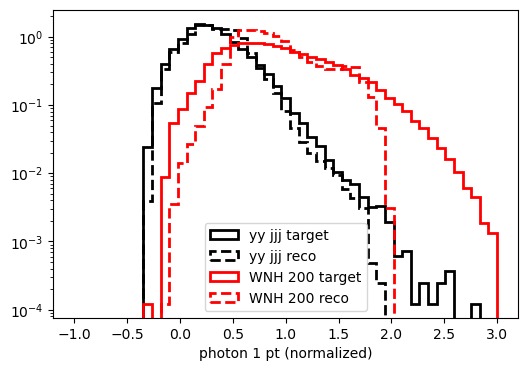

In [22]:
# photon 1 pt
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-1, 3, 50)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, 0, 0], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, 0] > 0.5, validation_features_reco[yy_jjj_mask, 0, 0], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, 0, 0], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, 0] > 0.5, validation_features_reco[wnh_200_mask, 0, 0], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("photon 1 pt (normalized)")
plt.show()


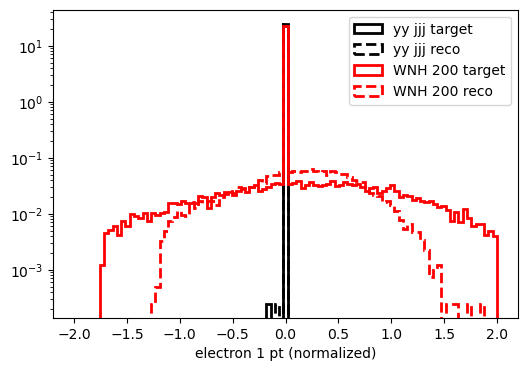

In [23]:
# electron 1 pt
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 2, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, 8, 0], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, 8] > 0.5, validation_features_reco[yy_jjj_mask, 8, 0], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, 8, 0], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, 8] > 0.5, validation_features_reco[wnh_200_mask, 8, 0], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("electron 1 pt (normalized)")
plt.show()


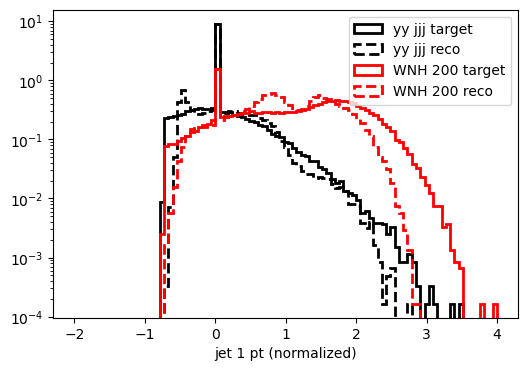

In [24]:
# jet 1 pt
object_index = 2
feature_index = 0
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 4, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 1 pt (normalized)")
plt.show()


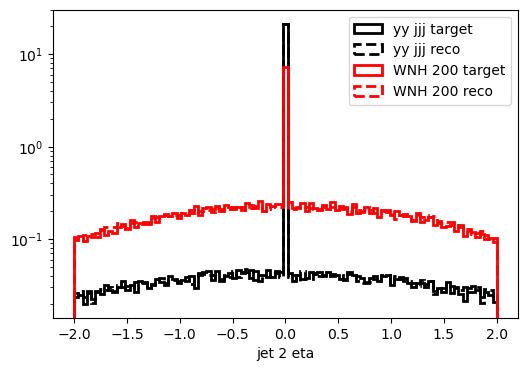

In [25]:
# jet 2 eta
object_index = 3
feature_index = 1
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-2, 2, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 2 eta")
plt.show()


### btag is binary

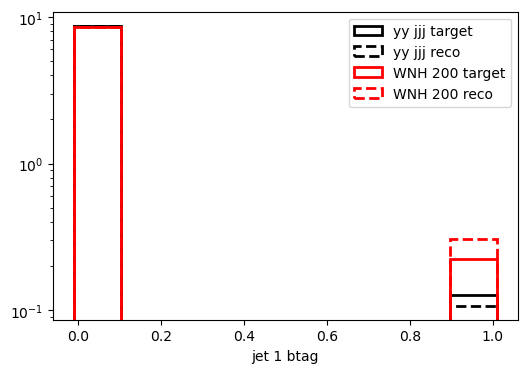

In [26]:
# jet 1 btag
object_index = 2
feature_index = 4
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-0.01, 1.01, 10)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
yy_jjj_present_reco_feature = np.where(yy_jjj_present_reco_feature > 0.5, 1, 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
wnh_200_present_reco_feature = np.where(wnh_200_present_reco_feature > 0.5, 1, 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("jet 1 btag")
plt.show()


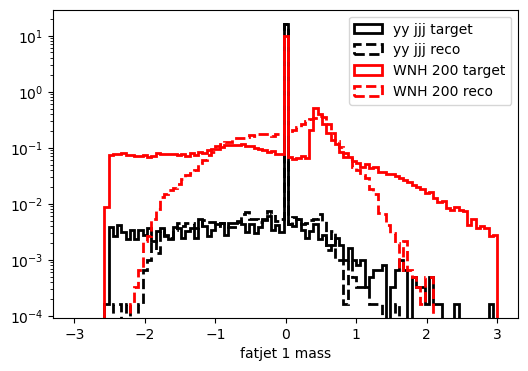

In [27]:
# fatjet 1 mass
object_index = 6
feature_index = 3
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-3, 3, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("fatjet 1 mass")
plt.show()


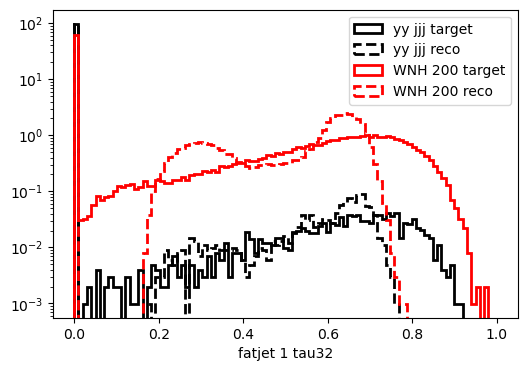

In [28]:
# fatjet 1 tau32
object_index = 6
feature_index = 5
f = plt.figure(figsize=(6, 4))
bins = np.linspace(0, 1, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("fatjet 1 tau32")
plt.show()


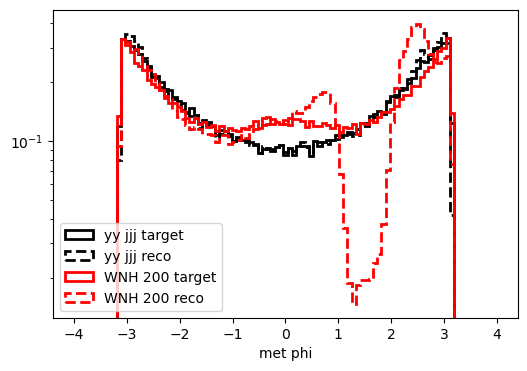

In [29]:
# met phi
object_index = -1
feature_index = 2
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-4, 4, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("met phi")
plt.show()


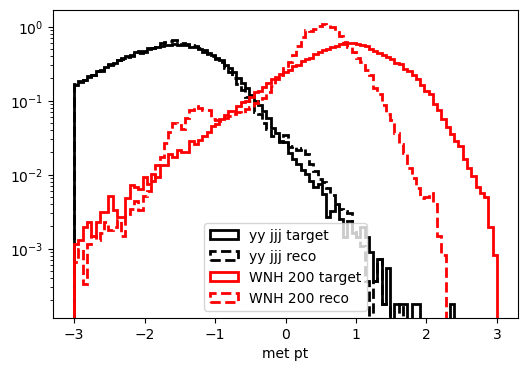

In [30]:
# met pt
object_index = -1
feature_index = 0
f = plt.figure(figsize=(6, 4))
bins = np.linspace(-3, 3, 100)
yy_jjj_mask = validation_process_id == 1
plt.hist(validation_features_target[yy_jjj_mask, object_index, feature_index], bins=bins, histtype='step', label="yy jjj target", density=True, linewidth=2, color="black")
# set non presenting features to 0
yy_jjj_present_reco_feature = np.where(validation_presence_reco[yy_jjj_mask, object_index] > 0.5, validation_features_reco[yy_jjj_mask, object_index, feature_index], 0)
plt.hist(yy_jjj_present_reco_feature, bins=bins, histtype='step', label="yy jjj reco", density=True, linewidth=2, color="black", ls='--')

wnh_200_mask = validation_process_id == -2
plt.hist(validation_features_target[wnh_200_mask, object_index, feature_index], bins=bins, histtype='step', label="WNH 200 target", density=True, linewidth=2, color="red")
# set non presenting features to 0
wnh_200_present_reco_feature = np.where(validation_presence_reco[wnh_200_mask, object_index] > 0.5, validation_features_reco[wnh_200_mask, object_index, feature_index], 0)
plt.hist(wnh_200_present_reco_feature, bins=bins, histtype='step', label="WNH 200 reco", density=True, linewidth=2, color="red", ls='--')

plt.legend()
plt.yscale('log')
plt.xlabel("met pt")
plt.show()


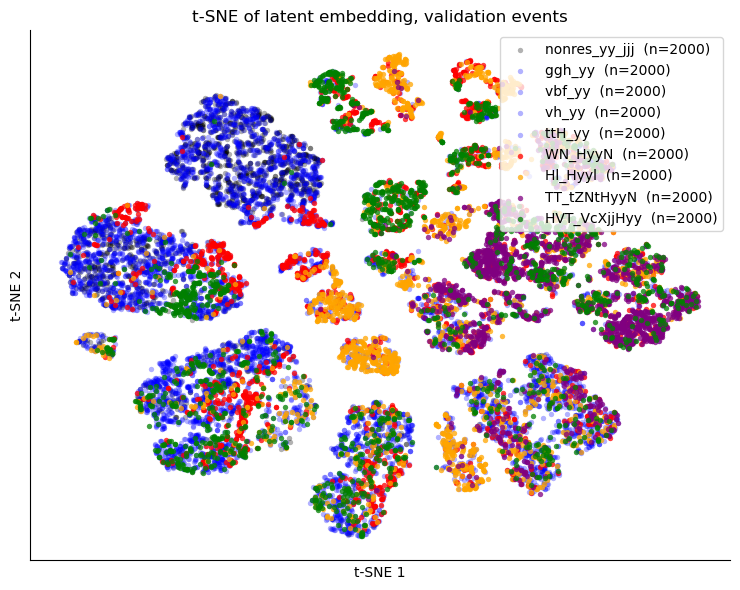

In [31]:
# ── t-SNE of the latent embedding on validation events, coloured by contrastive group ─────────
# Backgrounds (group_id >= 0) in cold colors, signal families (group_id < 0) in warm colors.
from sklearn.manifold import TSNE
from configs.file_dict import process_dict

N_PER_GROUP = 2000          # balanced subsample; t-SNE on ~18k points takes a minute or two on CPU
rng = np.random.default_rng(42)

# 1) latent and group label of the validation set
z = validation_latent_z
y = validation_group_id

# 2) balanced subsample per group so t-SNE is not dominated by the largest class
keep = np.concatenate([
    rng.choice(idx, size=min(N_PER_GROUP, len(idx)), replace=False)
    for gid in np.unique(y)
    for idx in [np.flatnonzero(y == gid)]
])
z_keep, y_keep = z[keep], y[keep]

# 3) t-SNE
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
emb2d = tsne.fit_transform(z_keep)

# 4) plot. Group name = process name without the mass-point suffix (WN_HyyN_150 -> WN_HyyN); backgrounds keep their name.
group_names = {}
for name, entry in process_dict.items():
    group_names.setdefault(entry["group_id"], name if entry["group_id"] >= 0 else "_".join(p for p in name.split("_") if not p.isdigit()))
cold = {0: "black", 1: "blue", 2: "blue", 3: "blue", 4: "blue"}   # SM backgrounds: yyjets, ggH, VBF, VH, ttH
warm = {-1: "red", -2: "orange", -3: "purple", -4: "green"}       # WN_HyyN, Hl_Hyyl, TT_tZNtHyyN, HVT_VcXjjHyy

fig, ax = plt.subplots(figsize=(7.5, 6))
for group, alpha in ((cold, 0.3), (warm, 0.75)):        # backgrounds first, signals drawn on top
    for gid, color in group.items():
        m = y_keep == gid
        if not m.any():
            continue
        ax.scatter(
            emb2d[m, 0], emb2d[m, 1],
            s=15, c=color, alpha=alpha, linewidths=0, rasterized=True,
            label=f"{group_names.get(gid, gid)}  (n={m.sum()})",
        )

ax.set_title("t-SNE of latent embedding, validation events")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


In [32]:
def make_tsne_group(group_id, n_per_background=1500, n_per_process=1500, seed=42):
    """t-SNE of the validation latent for the SM backgrounds plus the individual processes of `group_id`
    (e.g. -1 -> WN_HyyN_150 / 200 / 300 / 600, each in its own warm color)."""
    rng = np.random.default_rng(seed)
    z, gid, pid = validation_latent_z, validation_group_id, validation_process_id
    signal = {name: e["process_id"] for name, e in process_dict.items() if e["group_id"] == group_id}
    background = {name: e["process_id"] for name, e in process_dict.items() if e["group_id"] >= 0}

    # balanced subsample: each background process and each mass point contributes at most n events
    def pick(mask, n):
        idx = np.flatnonzero(mask)
        return rng.choice(idx, size=min(n, len(idx)), replace=False)

    keep = np.concatenate([pick(pid == p, n_per_background) for p in background.values()]
                          + [pick(pid == p, n_per_process) for p in signal.values()])
    emb2d = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=seed).fit_transform(z[keep])
    pid_keep = pid[keep]

    warm = ["#ffd700", "#d62728", "#ff7f0e", "#e377c2", "#8b0000", "#ff1493"]
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for name, p in background.items():                              # backgrounds first, signals drawn on top
        m = pid_keep == p
        if m.any():
            ax.scatter(emb2d[m, 0], emb2d[m, 1], s=15, c="black" if p == 1 else "blue", alpha=0.3,
                       linewidths=0, rasterized=True, label=f"{name}  (n={m.sum()})")
    for color, (name, p) in zip(warm, signal.items()):
        m = pid_keep == p
        if m.any():
            ax.scatter(emb2d[m, 0], emb2d[m, 1], s=15, color=color, alpha=0.8,
                       linewidths=0, rasterized=True, label=f"{name}  (n={m.sum()})")

    ax.set_title(f"t-SNE of latent embedding, validation events, group {group_id}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

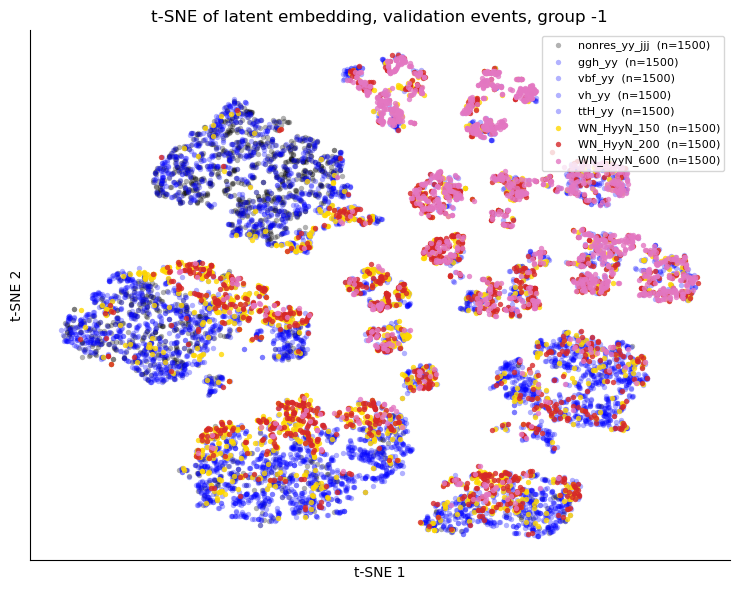

In [33]:
make_tsne_group(-1)

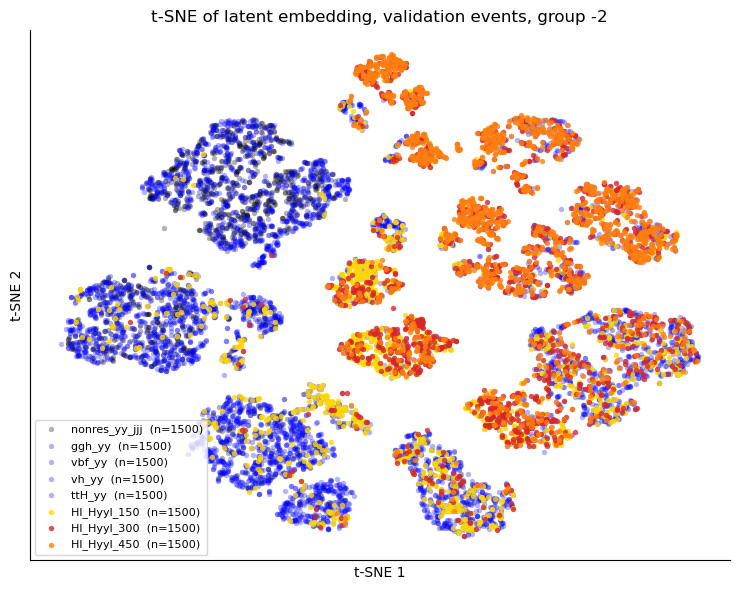

In [34]:
make_tsne_group(-2)

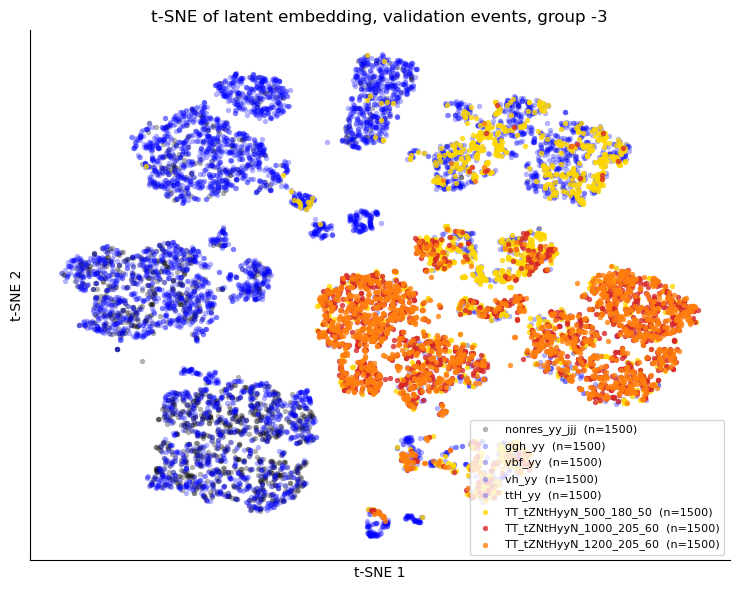

In [35]:
make_tsne_group(-3)

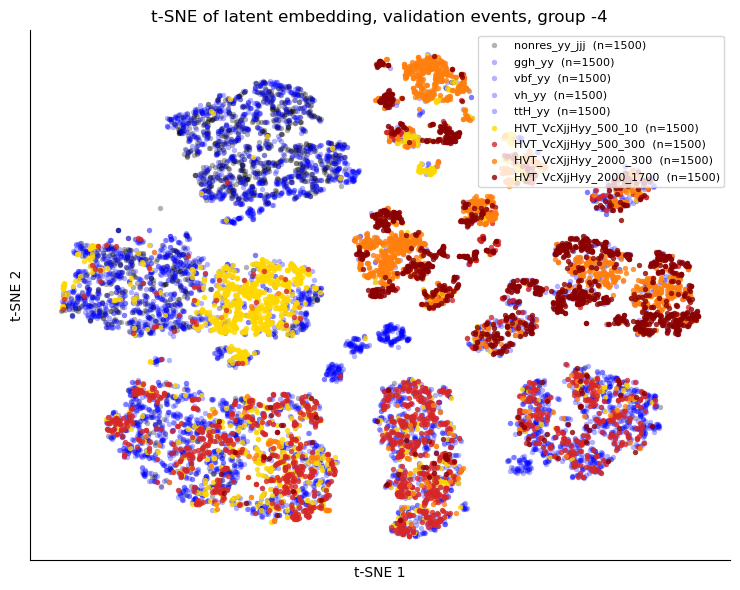

In [36]:
make_tsne_group(-4)

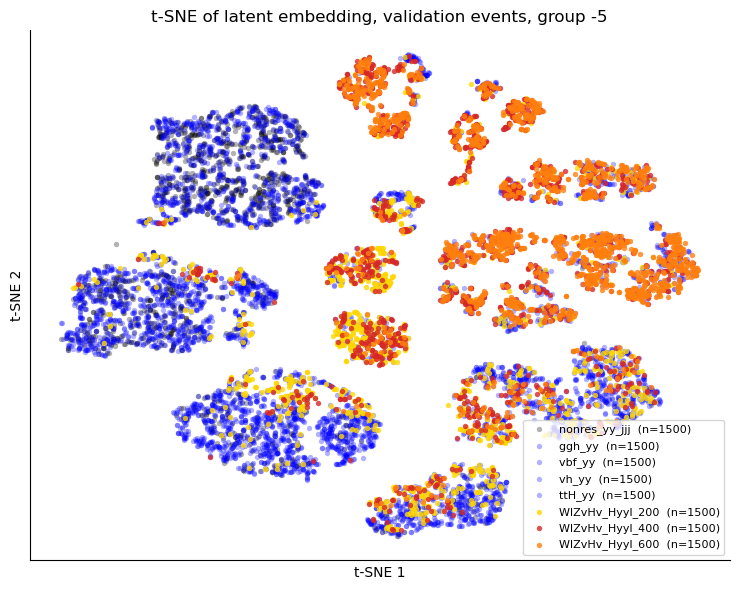

In [37]:
make_tsne_group(-5)

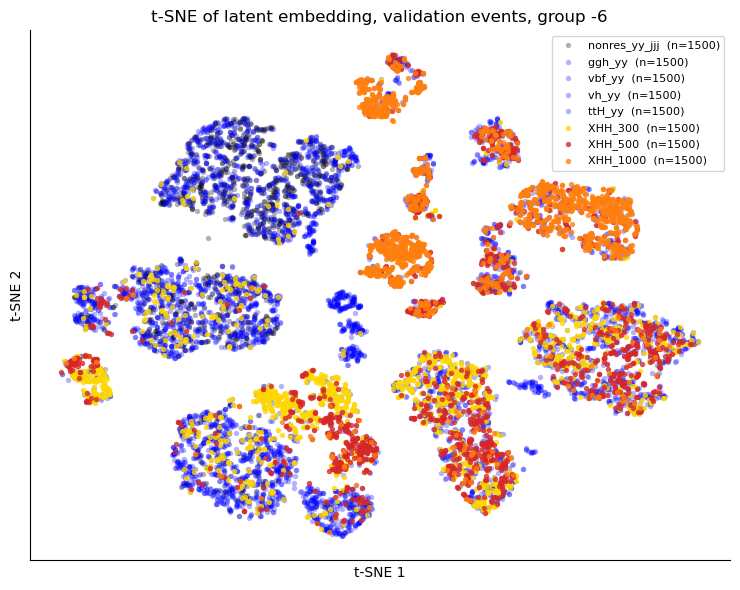

In [38]:
make_tsne_group(-6)

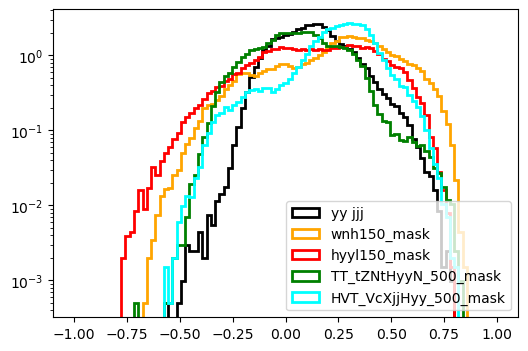

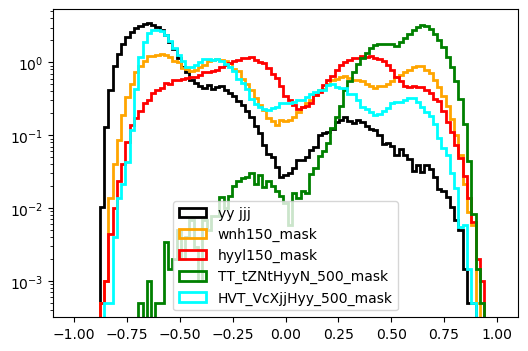

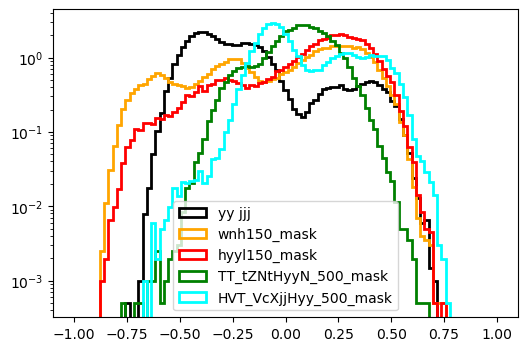

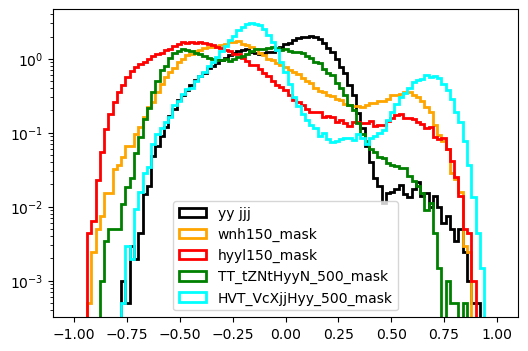

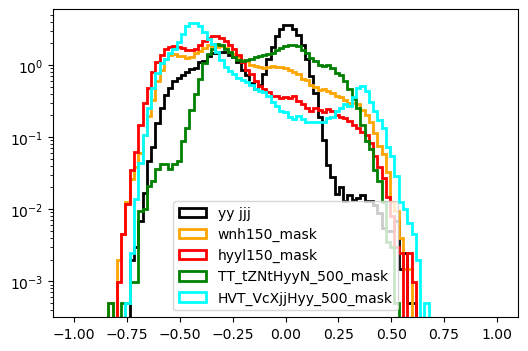

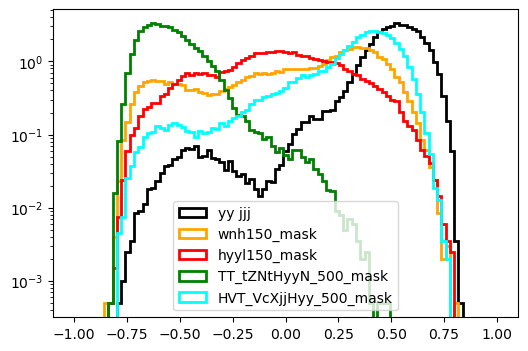

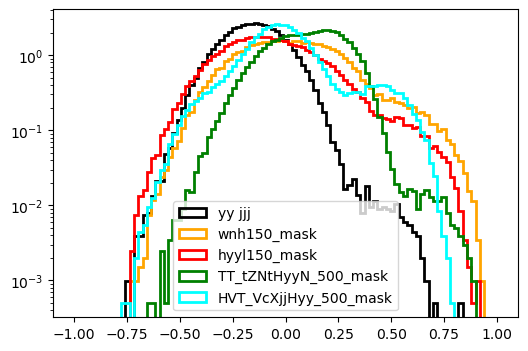

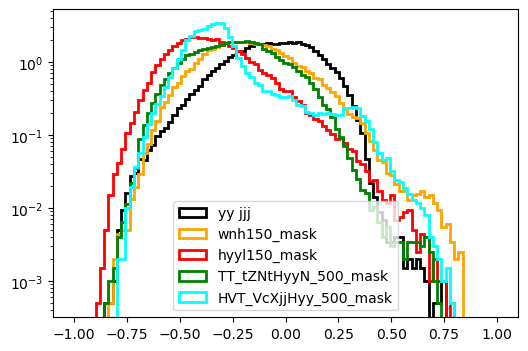

In [39]:
for dim in range(validation_latent_z.shape[1]):
    f = plt.figure(figsize=(6, 4))

    bins = np.linspace(-1, 1, 100)  # z is L2-normalized in the encoder, so every component lies in [-1, 1]
    yy_jjj_mask = validation_process_id == 1
    plt.hist(validation_latent_z[yy_jjj_mask, dim], bins=bins, histtype='step', label="yy jjj", density=True, linewidth=2, color="black")

    wnh150_mask = validation_process_id == -1
    plt.hist(validation_latent_z[wnh150_mask, dim], bins=bins, histtype='step', label="wnh150_mask", density=True, linewidth=2, color="orange")

    hyyl150_mask = validation_process_id == -5
    plt.hist(validation_latent_z[hyyl150_mask, dim], bins=bins, histtype='step', label="hyyl150_mask", density=True, linewidth=2, color="red")

    TT_tZNtHyyN_500_mask = validation_process_id == -8
    plt.hist(validation_latent_z[TT_tZNtHyyN_500_mask, dim], bins=bins, histtype='step', label="TT_tZNtHyyN_500_mask", density=True, linewidth=2, color="green")

    HVT_VcXjjHyy_500_mask = validation_process_id == -11
    plt.hist(validation_latent_z[HVT_VcXjjHyy_500_mask, dim], bins=bins, histtype='step', label="HVT_VcXjjHyy_500_mask", density=True, linewidth=2, color="cyan")
    
    plt.yscale("log")
    plt.legend()
    plt.show()
    